# 🏷️ Logistic Regression

The first classification algorithm in this series, and the direct bridge from the [Math Refresher](https://github.com/mdnuruzzamanKALLOL/Statistical-Machine-Learning-Foundation/tree/main/05_Math_Refresher)'s gradient descent to real predictive modeling. Despite the name, Logistic Regression is a **classifier**, not a regressor — it predicts the *probability* of a class, then thresholds that probability into a hard label.

📖 Full mathematical explanation (sigmoid derivation, log-loss, gradient derivation, regularization): [README.md](README.md)


## 1. Setup & Dataset

We use a 2-feature synthetic dataset (visualizable decision boundary) alongside the real-world Breast Cancer Wisconsin dataset (from the [Datasets catalog](https://github.com/mdnuruzzamanKALLOL/Datasets)) for a full end-to-end application later.


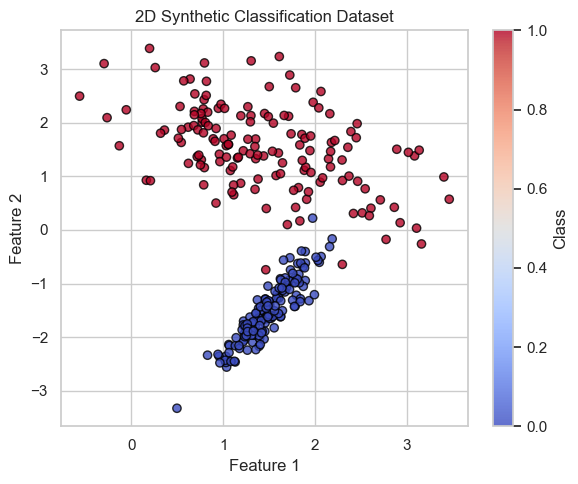

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score, log_loss
)

sns.set_theme(style="whitegrid")
np.random.seed(42)

# 2D synthetic dataset -- visualizable decision boundary
X_2d, y_2d = make_classification(
    n_samples=300, n_features=2, n_informative=2, n_redundant=0,
    n_clusters_per_class=1, class_sep=1.5, random_state=42
)

fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap="coolwarm", edgecolor="black", alpha=0.8)
ax.set_title("2D Synthetic Classification Dataset")
ax.set_xlabel("Feature 1"); ax.set_ylabel("Feature 2")
plt.colorbar(scatter, label="Class")
plt.tight_layout()
plt.show()


## 2. Why Not Linear Regression for Classification?

Fitting a straight line to a 0/1 target produces predictions outside $[0, 1]$ (nonsensical as probabilities) and is highly sensitive to outliers on the feature axis shifting the whole decision boundary. Logistic Regression fixes both by squashing the linear output through a bounded function.


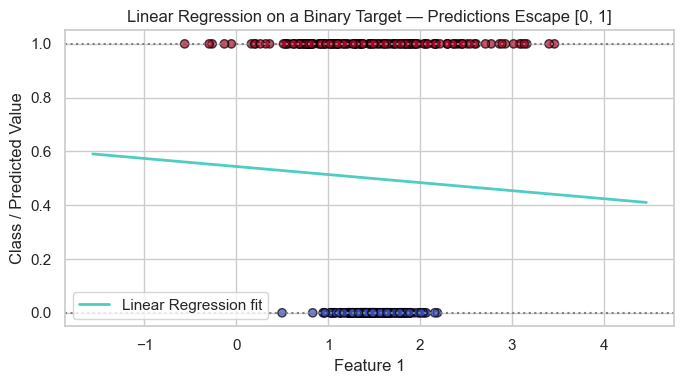

Prediction range: [0.41, 0.59] -- not a valid probability range


In [2]:
from sklearn.linear_model import LinearRegression

# Use a single feature to make the problem visualizable
x_single = X_2d[:, 0].reshape(-1, 1)

lin_reg = LinearRegression().fit(x_single, y_2d)
x_range = np.linspace(x_single.min() - 1, x_single.max() + 1, 200).reshape(-1, 1)
lin_preds = lin_reg.predict(x_range)

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(x_single, y_2d, c=y_2d, cmap="coolwarm", edgecolor="black", alpha=0.7)
ax.plot(x_range, lin_preds, color="#4ecdc4", linewidth=2, label="Linear Regression fit")
ax.axhline(0, color="gray", linestyle=":"); ax.axhline(1, color="gray", linestyle=":")
ax.set_title("Linear Regression on a Binary Target — Predictions Escape [0, 1]")
ax.set_xlabel("Feature 1"); ax.set_ylabel("Class / Predicted Value")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Prediction range: [{lin_preds.min():.2f}, {lin_preds.max():.2f}] -- not a valid probability range")


## 3. The Sigmoid Function

The sigmoid squashes any real number into $(0, 1)$ — turning a linear score into something interpretable as a probability. Formula and properties in the README.


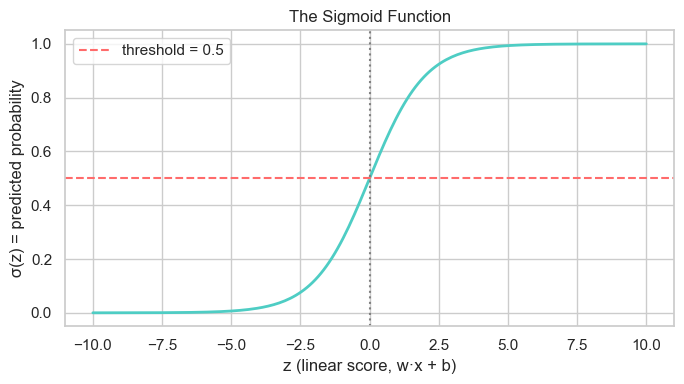

sigmoid(0)   = 0.5
sigmoid(5)   = 0.9933
sigmoid(-5)  = 0.0067


In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_range = np.linspace(-10, 10, 200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z_range, sigmoid(z_range), color="#4ecdc4", linewidth=2)
ax.axhline(0.5, color="#ff6b6b", linestyle="--", label="threshold = 0.5")
ax.axvline(0, color="gray", linestyle=":")
ax.set_title("The Sigmoid Function")
ax.set_xlabel("z (linear score, w·x + b)"); ax.set_ylabel("σ(z) = predicted probability")
ax.legend()
plt.tight_layout()
plt.show()

print("sigmoid(0)   =", sigmoid(0))
print("sigmoid(5)   =", sigmoid(5).round(4))
print("sigmoid(-5)  =", sigmoid(-5).round(4))


## 4. Log Loss (Binary Cross-Entropy)

Log loss penalizes confident-and-wrong predictions far more heavily than squared error would — exactly the behavior wanted from a probability-calibrated classifier's cost function. Formula and intuition in the README.


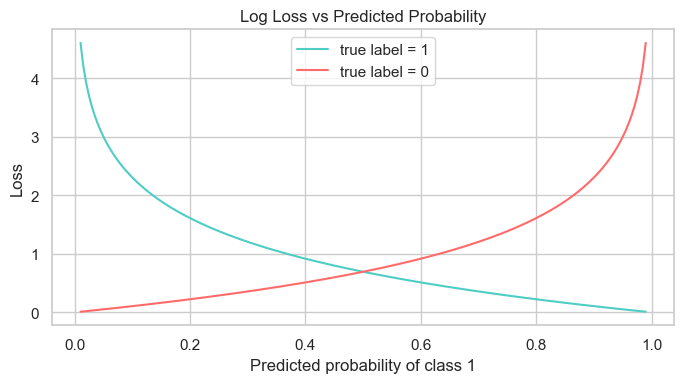

Loss when true=1, predicted=0.99 (confident & correct): 0.0101
Loss when true=1, predicted=0.01 (confident & WRONG):   4.6052


In [4]:
def log_loss_manual(y_true, y_pred_proba, eps=1e-15):
    y_pred_proba = np.clip(y_pred_proba, eps, 1 - eps)   # avoid log(0)
    return -np.mean(y_true * np.log(y_pred_proba) + (1 - y_true) * np.log(1 - y_pred_proba))

# Visualize the per-sample loss curve for a true label of 1
p_range = np.linspace(0.01, 0.99, 200)
loss_if_true_1 = -np.log(p_range)
loss_if_true_0 = -np.log(1 - p_range)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(p_range, loss_if_true_1, color="#4ecdc4", label="true label = 1")
ax.plot(p_range, loss_if_true_0, color="#ff6b6b", label="true label = 0")
ax.set_title("Log Loss vs Predicted Probability")
ax.set_xlabel("Predicted probability of class 1")
ax.set_ylabel("Loss")
ax.legend()
plt.tight_layout()
plt.show()

print("Loss when true=1, predicted=0.99 (confident & correct):", round(-np.log(0.99), 4))
print("Loss when true=1, predicted=0.01 (confident & WRONG):  ", round(-np.log(0.01), 4))


## 5. From-Scratch Implementation — Gradient Descent

The exact same update rule from the Math Refresher (`x_{t+1} = x_t - η∇f(x_t)`), applied to logistic regression's weights. This makes the connection between "Math Refresher's gradient descent" and "a real classifier training" completely explicit.


In [5]:
def train_logistic_regression(X, y, lr=0.1, n_iterations=1000):
    n_samples, n_features = X.shape
    weights = np.zeros(n_features)
    bias = 0.0
    loss_history = []

    for _ in range(n_iterations):
        z = X @ weights + bias
        y_pred = sigmoid(z)

        # Gradients of log loss w.r.t. weights and bias (derivation in README)
        dw = (1 / n_samples) * X.T @ (y_pred - y)
        db = (1 / n_samples) * np.sum(y_pred - y)

        weights -= lr * dw
        bias -= lr * db
        loss_history.append(log_loss_manual(y, y_pred))

    return weights, bias, loss_history

# Standardize features first -- gradient descent converges far more reliably on scaled data
scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

w_scratch, b_scratch, loss_history = train_logistic_regression(X_2d_scaled, y_2d, lr=0.5, n_iterations=1000)
print("Learned weights:", w_scratch.round(4))
print("Learned bias:   ", round(b_scratch, 4))


Learned weights: [0.6401 7.2252]
Learned bias:    0.206


## 6. Training Curve — Loss Decreasing Over Iterations

A correctly-implemented gradient descent should show loss decreasing monotonically (or very close to it) and flattening out — exactly the same convergence shape as the Math Refresher's 1D toy example, now on a real cost function.


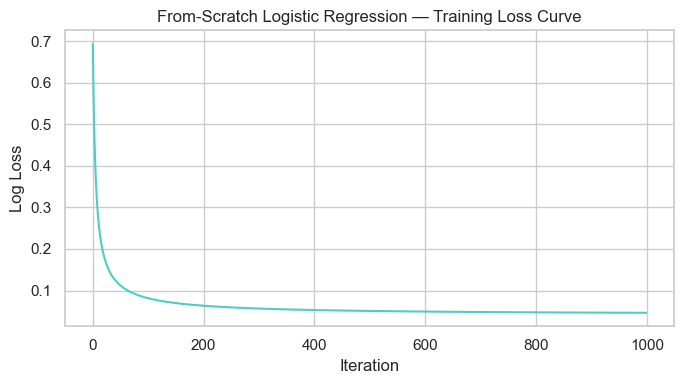

Loss at start: 0.6931
Loss at end:   0.0466


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(loss_history, color="#4ecdc4")
ax.set_title("From-Scratch Logistic Regression — Training Loss Curve")
ax.set_xlabel("Iteration"); ax.set_ylabel("Log Loss")
plt.tight_layout()
plt.show()

print(f"Loss at start: {loss_history[0]:.4f}")
print(f"Loss at end:   {loss_history[-1]:.4f}")


## 7. Visualizing the Learned Decision Boundary

The **decision boundary** is where $\sigma(w \cdot x + b) = 0.5$, equivalently $w \cdot x + b = 0$ — a straight line for 2 features, since Logistic Regression is fundamentally a *linear* classifier (curved boundaries need engineered polynomial features, same idea as topic 04's `PolynomialFeatures`).


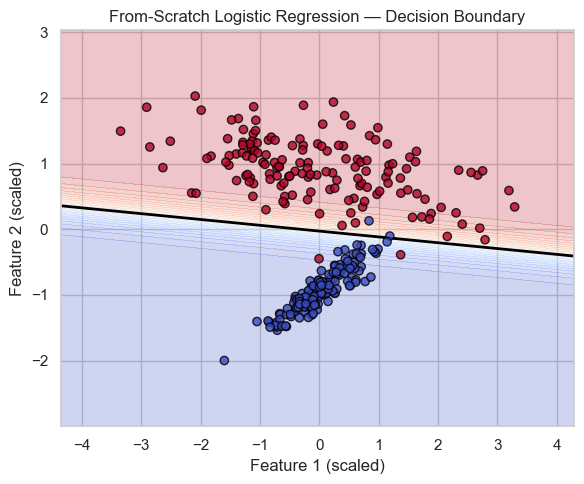

In [7]:
def plot_decision_boundary(X, y, weights, bias, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="black", alpha=0.8, zorder=3)

    x1_range = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)
    x2_range = np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200)
    xx1, xx2 = np.meshgrid(x1_range, x2_range)
    grid = np.c_[xx1.ravel(), xx2.ravel()]
    probs = sigmoid(grid @ weights + bias).reshape(xx1.shape)

    ax.contourf(xx1, xx2, probs, levels=25, cmap="coolwarm", alpha=0.25, zorder=1)
    ax.contour(xx1, xx2, probs, levels=[0.5], colors="black", linewidths=2, zorder=2)
    ax.set_title(title)
    ax.set_xlabel("Feature 1 (scaled)"); ax.set_ylabel("Feature 2 (scaled)")
    plt.tight_layout()
    plt.show()

plot_decision_boundary(X_2d_scaled, y_2d, w_scratch, b_scratch, "From-Scratch Logistic Regression — Decision Boundary")


## 8. Comparing Against scikit-learn

Verifying the from-scratch implementation against `sklearn.linear_model.LogisticRegression` — coefficients should be close (not identical, since sklearn applies L2 regularization by default and uses a different optimizer).


From-scratch weights:  [0.6401 7.2252] | bias: 0.206
sklearn weights:       [0.3694 4.6978] | bias: 0.1271

-> Close but not identical -- sklearn's default L2 regularization (C=1.0) shrinks weights slightly
   compared to our unregularized from-scratch version. See section 12 for regularization's effect.


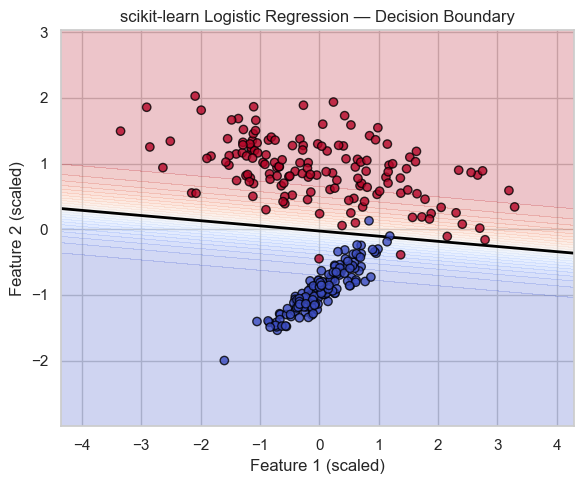

In [8]:
sklearn_model = LogisticRegression()
sklearn_model.fit(X_2d_scaled, y_2d)

print("From-scratch weights: ", w_scratch.round(4), "| bias:", round(b_scratch, 4))
print("sklearn weights:      ", sklearn_model.coef_[0].round(4), "| bias:", round(sklearn_model.intercept_[0], 4))
print("\n-> Close but not identical -- sklearn's default L2 regularization (C=1.0) shrinks weights slightly")
print("   compared to our unregularized from-scratch version. See section 12 for regularization's effect.")

plot_decision_boundary(X_2d_scaled, y_2d, sklearn_model.coef_[0], sklearn_model.intercept_[0], "scikit-learn Logistic Regression — Decision Boundary")


## 9. Predicted Probabilities vs Hard Predictions

`predict_proba()` returns the actual $P(\text{class}=1)$; `predict()` just thresholds it at 0.5. Looking at the probabilities directly reveals the model's *confidence*, which a hard 0/1 label throws away.


In [9]:
sample_points = X_2d_scaled[:5]
probabilities = sklearn_model.predict_proba(sample_points)
hard_predictions = sklearn_model.predict(sample_points)

comparison = pd.DataFrame({
    "P(class=0)": probabilities[:, 0].round(3),
    "P(class=1)": probabilities[:, 1].round(3),
    "hard_prediction": hard_predictions,
    "true_label": y_2d[:5],
})
comparison


,P(class=0),P(class=1),hard_prediction,true_label
0,0.996,0.004,0,0
1,0.024,0.976,1,1
2,0.999,0.001,0,0
3,0.184,0.816,1,1
4,0.016,0.984,1,1


## 10. Threshold Tuning

The 0.5 threshold is a default, not a law. Raising it makes the model more conservative about predicting class 1 (fewer false positives, more false negatives); lowering it does the opposite. The right threshold depends on which error type is costlier for the specific problem (e.g. medical screening vs spam filtering).


In [10]:
probs_all = sklearn_model.predict_proba(X_2d_scaled)[:, 1]

for threshold in [0.3, 0.5, 0.7]:
    preds_at_threshold = (probs_all >= threshold).astype(int)
    acc = accuracy_score(y_2d, preds_at_threshold)
    prec = precision_score(y_2d, preds_at_threshold)
    rec = recall_score(y_2d, preds_at_threshold)
    print(f"threshold={threshold}: accuracy={acc:.3f}, precision={prec:.3f}, recall={rec:.3f}")

print("\n-> Lower threshold -> more positives predicted -> recall tends up, precision tends down (and vice versa).")


threshold=0.3: accuracy=0.977, precision=0.967, recall=0.987
threshold=0.5: accuracy=0.987, precision=0.987, recall=0.987
threshold=0.7: accuracy=0.977, precision=0.993, recall=0.960

-> Lower threshold -> more positives predicted -> recall tends up, precision tends down (and vice versa).


## 11. Confusion Matrix

A confusion matrix breaks predictions into 4 buckets — the raw material every classification metric (accuracy, precision, recall, F1) is computed from. Full metric formulas live in the Model Evaluation & Tuning notebooks; this is the first hands-on look.


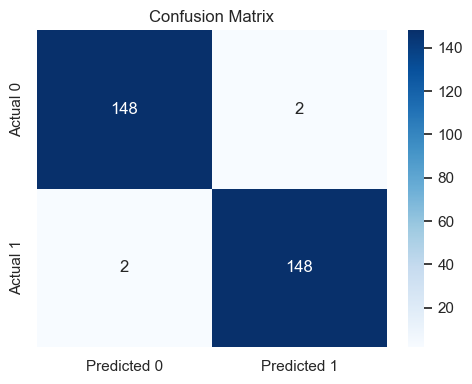

True Negatives: 148, False Positives: 2, False Negatives: 2, True Positives: 148


In [11]:
y_pred_default = sklearn_model.predict(X_2d_scaled)
cm = confusion_matrix(y_2d, y_pred_default)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Predicted 0", "Predicted 1"], yticklabels=["Actual 0", "Actual 1"])
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}")


## 12. Core Classification Metrics

Quick definitions (full derivations in Model Evaluation & Tuning): **Accuracy** = correct / total. **Precision** = of predicted positives, how many were right. **Recall** = of actual positives, how many were caught. **F1** = harmonic mean of precision and recall.


In [12]:
print(f"Accuracy:  {accuracy_score(y_2d, y_pred_default):.4f}")
print(f"Precision: {precision_score(y_2d, y_pred_default):.4f}")
print(f"Recall:    {recall_score(y_2d, y_pred_default):.4f}")
print(f"F1 Score:  {f1_score(y_2d, y_pred_default):.4f}")
print(f"Log Loss:  {log_loss(y_2d, probs_all):.4f}")


Accuracy:  0.9867
Precision: 0.9867
Recall:    0.9867
F1 Score:  0.9867
Log Loss:  0.0663


## 13. ROC Curve & AUC

The ROC curve plots True Positive Rate vs False Positive Rate across *every possible threshold* at once — a single-number summary (AUC, Area Under the Curve) of how well the model separates the two classes, independent of any one threshold choice.


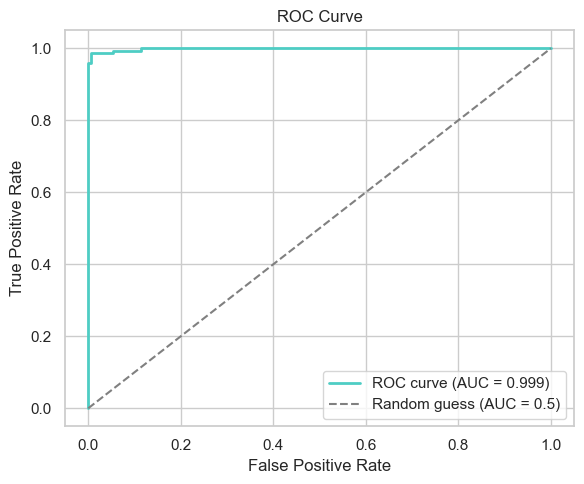

AUC: 0.9987 (1.0 = perfect separation, 0.5 = random guessing)


In [13]:
fpr, tpr, thresholds = roc_curve(y_2d, probs_all)
auc_score = roc_auc_score(y_2d, probs_all)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="#4ecdc4", linewidth=2, label=f"ROC curve (AUC = {auc_score:.3f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random guess (AUC = 0.5)")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
plt.tight_layout()
plt.show()

print(f"AUC: {auc_score:.4f} (1.0 = perfect separation, 0.5 = random guessing)")


## 14. Regularization — L1 vs L2 Penalty (the `C` Parameter)

Logistic Regression supports the same L1/L2 penalties as Ridge/Lasso (Math Refresher §Part I.1), controlled by `C` — the **inverse** of regularization strength (small `C` = strong regularization, unlike Ridge's `alpha` which is direct).


        feature_1_coef  feature_2_coef
0.01          0.003781        0.807542
0.10          0.121924        2.389236
1.00          0.369377        4.697794
10.00         0.654808        7.413100
100.00        0.780532        8.835053


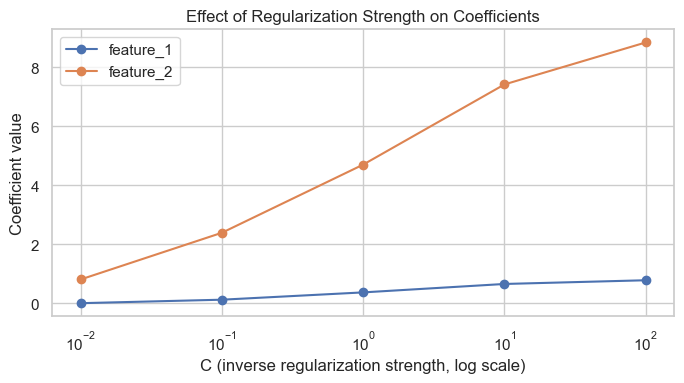

In [14]:
from sklearn.linear_model import LogisticRegression as LR

C_values = [0.01, 0.1, 1, 10, 100]
coef_paths = []

for C in C_values:
    model_c = LR(C=C, max_iter=1000)
    model_c.fit(X_2d_scaled, y_2d)
    coef_paths.append(model_c.coef_[0])

coef_df = pd.DataFrame(coef_paths, index=C_values, columns=["feature_1_coef", "feature_2_coef"])
print(coef_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(C_values, coef_df["feature_1_coef"], marker="o", label="feature_1")
ax.plot(C_values, coef_df["feature_2_coef"], marker="o", label="feature_2")
ax.set_xscale("log")
ax.set_xlabel("C (inverse regularization strength, log scale)")
ax.set_ylabel("Coefficient value")
ax.set_title("Effect of Regularization Strength on Coefficients")
ax.legend()
plt.tight_layout()
plt.show()


## 15. Multiclass Logistic Regression

Real problems often have more than 2 classes. scikit-learn handles this via **multinomial** (softmax, generalizes the sigmoid to $k$ classes at once) or **one-vs-rest** (train $k$ separate binary classifiers, pick the highest-confidence one) strategies — both usable with the exact same `.fit()`/`.predict()` API.


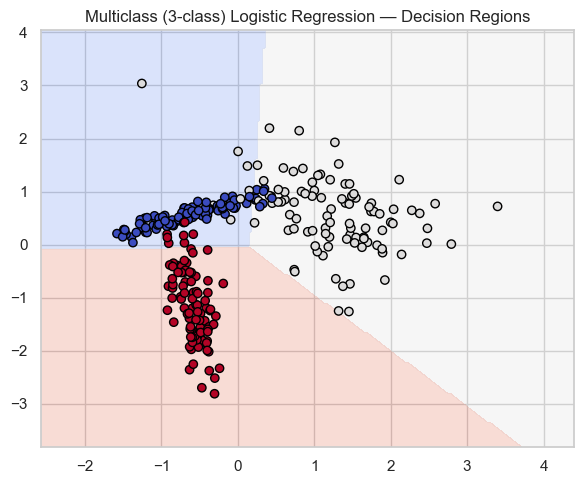

Training accuracy: 0.92


In [15]:
from sklearn.datasets import make_classification as make_clf

X_multi, y_multi = make_clf(n_samples=300, n_features=2, n_informative=2, n_redundant=0,
                              n_classes=3, n_clusters_per_class=1, random_state=42)
X_multi_scaled = StandardScaler().fit_transform(X_multi)

multi_model = LogisticRegression(max_iter=1000)   # newer sklearn auto-selects multinomial for multi-class problems
multi_model.fit(X_multi_scaled, y_multi)

x1_range = np.linspace(X_multi_scaled[:, 0].min() - 1, X_multi_scaled[:, 0].max() + 1, 200)
x2_range = np.linspace(X_multi_scaled[:, 1].min() - 1, X_multi_scaled[:, 1].max() + 1, 200)
xx1, xx2 = np.meshgrid(x1_range, x2_range)
preds_grid = multi_model.predict(np.c_[xx1.ravel(), xx2.ravel()]).reshape(xx1.shape)

fig, ax = plt.subplots(figsize=(6, 5))
ax.contourf(xx1, xx2, preds_grid, levels=2, cmap="coolwarm", alpha=0.25)
ax.scatter(X_multi_scaled[:, 0], X_multi_scaled[:, 1], c=y_multi, cmap="coolwarm", edgecolor="black")
ax.set_title("Multiclass (3-class) Logistic Regression — Decision Regions")
plt.tight_layout()
plt.show()

print("Training accuracy:", round(accuracy_score(y_multi, multi_model.predict(X_multi_scaled)), 4))


## 16. Real Dataset — Breast Cancer Wisconsin

Applying the full pipeline (split → scale → fit → evaluate) to a real medical dataset, exactly the workflow set up across the Foundation repo's topics 03–04.


In [16]:
cancer = load_breast_cancer(as_frame=True)
X_cancer, y_cancer = cancer.data, cancer.target

X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, test_size=0.2, stratify=y_cancer, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)   # fit on train only, transform test -- no leakage

cancer_model = LogisticRegression(max_iter=5000)
cancer_model.fit(X_train_scaled, y_train)

test_preds = cancer_model.predict(X_test_scaled)
test_probs = cancer_model.predict_proba(X_test_scaled)[:, 1]

print(f"Test accuracy:  {accuracy_score(y_test, test_preds):.4f}")
print(f"Test precision: {precision_score(y_test, test_preds):.4f}")
print(f"Test recall:    {recall_score(y_test, test_preds):.4f}")
print(f"Test AUC:       {roc_auc_score(y_test, test_probs):.4f}")


Test accuracy:  0.9825
Test precision: 0.9861
Test recall:    0.9861
Test AUC:       0.9954


## 17. Feature Importance via Coefficients

For a linear model on **scaled** features, coefficient magnitude directly reflects feature importance — a feature with a large |coefficient| moves the prediction more per unit change than one with a small |coefficient|. (This shortcut only works because features are on the same scale — see topic 03's scaling notebook for why.)


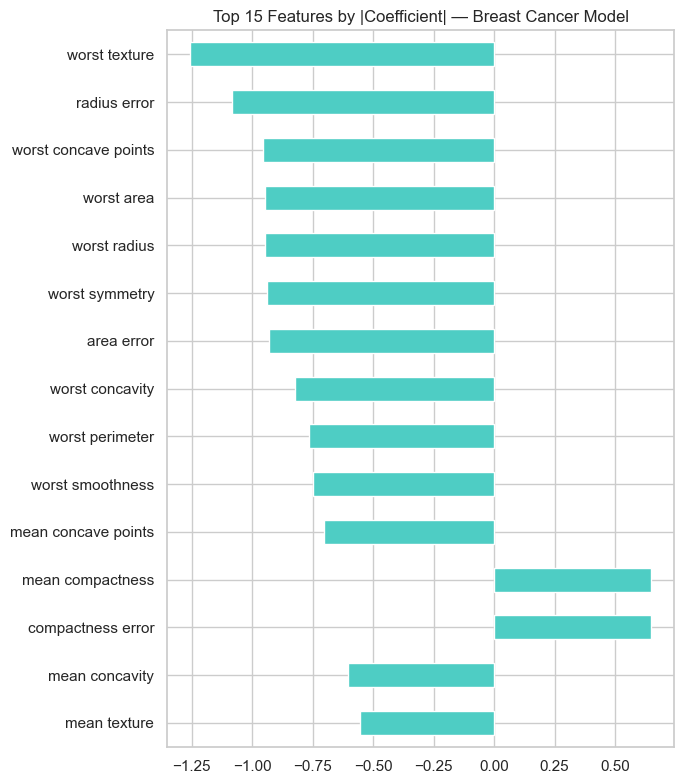

worst texture          -1.255088
radius error           -1.082965
worst concave points   -0.953686
worst area             -0.947756
worst radius           -0.947616
worst symmetry         -0.939181
area error             -0.929104
worst concavity        -0.823151
worst perimeter        -0.763220
worst smoothness       -0.746625
dtype: float64


In [17]:
coef_importance = pd.Series(cancer_model.coef_[0], index=cancer.feature_names).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(7, 8))
coef_importance.head(15).plot(kind="barh", ax=ax, color="#4ecdc4")
ax.set_title("Top 15 Features by |Coefficient| — Breast Cancer Model")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(coef_importance.head(10))


## ✅ Key Takeaways

- Logistic Regression is a **linear classifier**: it learns a straight-line (or hyperplane) decision boundary, then wraps the linear score in a sigmoid to produce a calibrated probability.
- The from-scratch gradient descent implementation here is *literally* the Math Refresher's update rule — same formula, applied to a real cost function (log loss) instead of a toy one.
- `predict_proba()` carries more information than `predict()` — always prefer it when threshold choice matters (it usually does).
- Regularization strength (`C`) trades off fitting the training data tightly vs. keeping coefficients small — smaller `C` means stronger regularization, the opposite convention from Ridge's `alpha`.
- Multiclass logistic regression is the same algorithm, generalized via softmax or one-vs-rest — no new concept, just more classes.
- Always fit scalers/encoders on the training split only (section 16) — this is the leakage-prevention rule from topic 03, applied for real here.

**Next up:** [02_KNN_Classifier](../02_KNN_Classifier/) — a completely different approach to classification: no learned parameters at all, just distance to training examples.
